In [1]:
%load_ext autoreload
%autoreload 2

# 04 — Structural Correlates of Model Disagreement

Week 3 anchor question: does structural context (solvent exposure, secondary
structure, local packing) explain *where* the 95 zero-shot models disagree
(Week 1), and does it explain *why* the cluster accuracy ranking from Week 2
(`newer_plm > msa_based > autoregressive_plm > inverse_folding_mixed > structure_aware`)
holds or breaks down?

**Structural coverage**: AlphaFold DB has reference structures for 4 of the 5
pilots. `A0A192B1T2_9HIV1_Haddox_2018` (HIV Env) is an unreviewed, hypervariable
TrEMBL sequence with no AlphaFold model — it is excluded from every structural
analysis in this notebook and called out explicitly wherever it drops out.

All figures → `results/figures/`, tables → `results/tables/`,
intermediates → `data/processed/`, log → `results/ARTIFACTS_LOG.csv`.


In [2]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.proteingym_loader import load_dms_scores, get_model_columns
from src.data.alphafold_fetcher import fetch_alphafold_structure
from src.data.structural_features import compute_structural_features
from src.analysis.clustering import assign_clusters, label_clusters_manually
from src.analysis.accuracy import cluster_majority_vote, per_cluster_accuracy
from src.analysis.meta_confidence import (
    attach_structural_features,
    disagreement_structural_correlation,
    disagreement_by_secondary_structure,
    cluster_accuracy_by_structural_bin,
    trust_map,
)
from src.utils.persistence import save_figure, save_table, save_processed

NB = "04_structural_correlates"

sns.set_theme(style="whitegrid", font_scale=0.9)
plt.rcParams["figure.dpi"] = 120


## 1  Load data

Load the 5 pilots (now carrying `DMS_score_bin` and `position`) and join the
pre-computed `{model}_binary` columns + disagreement/score-spread columns from
`pilot_binarized_scores.parquet` (Week 1), and the 95x95 pairwise kappa matrix
+ cluster assignments from Week 2.


In [3]:
PILOTS = [
    "A4_HUMAN_Seuma_2022",
    "ADRB2_HUMAN_Jones_2020",
    "ACE2_HUMAN_Chan_2020",
    "AMIE_PSEAE_Wrenbeck_2017",
    "A0A192B1T2_9HIV1_Haddox_2018",
]

raw = load_dms_scores("../data/raw", dms_ids=PILOTS)
models = get_model_columns(raw)

binarized = pd.read_parquet("../data/processed/pilot_binarized_scores.parquet")
df = raw[["dms_id", "mutant", "position", "DMS_score_bin"]].merge(
    binarized, on=["dms_id", "mutant"], how="inner"
)

n_single = df["position"].notna().sum()
print(f"{len(df):,} variants total, {n_single:,} single-mutant ({n_single/len(df):.1%}) -- "
      f"only single-mutants can carry a structural feature.")
print(df.groupby("dms_id")["position"].apply(lambda s: s.notna().mean()).rename("frac_single_mutant"))

kappa = pd.read_csv("../results/tables/pairwise_kappa_matrix.csv", index_col=0)
cluster_ids = assign_clusters(kappa, n_clusters=5, method="ward")
CLUSTER_LABELS = {
    "cluster_0": "structure_aware",
    "cluster_1": "inverse_folding_mixed",
    "cluster_2": "autoregressive_plm",
    "cluster_3": "msa_based",
    "cluster_4": "newer_plm",
}
cluster_assignments = label_clusters_manually(cluster_ids, CLUSTER_LABELS)
cluster_votes = cluster_majority_vote(df, cluster_assignments["cluster_label"])

all_binary_cols = [f"{m}_binary" for m in models]
mean_vote_all = df[all_binary_cols].astype(float).mean(axis=1)
ensemble_vote = pd.Series(pd.NA, index=df.index, dtype="Int8")
ensemble_vote[mean_vote_all > 0.5] = 1
ensemble_vote[mean_vote_all < 0.5] = 0


Loading assays:   0%|          | 0/5 [00:00<?, ?assay/s]

Loading assays:  20%|██        | 1/5 [00:00<00:01,  3.50assay/s]

Loading assays:  40%|████      | 2/5 [00:00<00:00,  3.02assay/s]

Loading assays:  80%|████████  | 4/5 [00:00<00:00,  5.29assay/s]

Loading assays: 100%|██████████| 5/5 [00:00<00:00,  6.08assay/s]

Loading assays: 100%|██████████| 5/5 [00:00<00:00,  5.16assay/s]


Proteins (UniProt IDs) : 5
DMS assays             : 5
Zero-shot models       : 95
Total variant rows     : 43,638
Models found           : ['Site_Independent', 'EVmutation', 'DeepSequence_single', 'DeepSequence_ensemble', 'EVE_single', 'EVE_ensemble']...

43,638 variants total, 29,623 single-mutant (67.9%) -- only single-mutants can carry a structural feature.
dms_id
A0A192B1T2_9HIV1_Haddox_2018    1.000000
A4_HUMAN_Seuma_2022             0.053744
ACE2_HUMAN_Chan_2020            1.000000
ADRB2_HUMAN_Jones_2020          1.000000
AMIE_PSEAE_Wrenbeck_2017        1.000000
Name: frac_single_mutant, dtype: float64


## 2  Fetch AlphaFold structures & compute structural features

One AlphaFold PDB model per protein (cached under `data/raw/structures/`,
gitignored like other raw data), parsed with `biotite` for per-residue:
RSA (relative solvent accessibility, Tien et al. 2013 normalization),
secondary structure (P-SEA: helix/sheet/coil), local contact density
(# CA neighbors within 10 A), and pLDDT confidence (from the B-factor field).


In [4]:
PROTEIN_IDS = sorted(df["protein_id"].dropna().unique())
print("Proteins:", PROTEIN_IDS)

structural_features = {}
structure_fetch_log = []
for protein_id in PROTEIN_IDS:
    pdb_path = fetch_alphafold_structure(protein_id, dest_dir="../data/raw/structures")
    if pdb_path is None:
        structure_fetch_log.append({"protein_id": protein_id, "status": "no_alphafold_model"})
        print(f"  {protein_id}: NO AlphaFold model available -- excluded from structural analysis")
        continue
    feats = compute_structural_features(str(pdb_path))
    structural_features[protein_id] = feats
    structure_fetch_log.append({"protein_id": protein_id, "status": "ok", "n_residues": len(feats)})
    print(f"  {protein_id}: {len(feats)} residues, RSA range [{feats['rsa'].min():.2f}, {feats['rsa'].max():.2f}]")

structure_fetch_log_df = pd.DataFrame(structure_fetch_log)
save_table(
    structure_fetch_log_df, "structure_fetch_log", notebook=NB,
    description="AlphaFold structure fetch status per pilot protein -- which proteins have a reference structure and which were excluded",
)

structural_features_table = pd.concat(
    [feats.reset_index().assign(protein_id=pid) for pid, feats in structural_features.items()],
    ignore_index=True,
)[["protein_id", "position", "wt_aa_pdb", "plddt", "sasa", "rsa", "secondary_structure", "contact_density"]]
save_table(
    structural_features_table, "structural_features_by_protein", notebook=NB,
    description="Per-residue AlphaFold-derived structural features (RSA, secondary structure, contact density, pLDDT) for the 4 pilot proteins with a reference structure",
)


Proteins: ['A0A192B1T2_9HIV1', 'A4_HUMAN', 'ACE2_HUMAN', 'ADRB2_HUMAN', 'AMIE_PSEAE']
  A0A192B1T2_9HIV1: NO AlphaFold model available -- excluded from structural analysis


  A4_HUMAN: 770 residues, RSA range [0.00, 1.11]


  ACE2_HUMAN: 805 residues, RSA range [0.00, 1.13]


  ADRB2_HUMAN: 413 residues, RSA range [0.00, 1.23]


  AMIE_PSEAE: 346 residues, RSA range [0.00, 1.11]
  [saved table]  results/tables/structure_fetch_log.csv
  [saved table]  results/tables/structural_features_by_protein.csv


PosixPath('/Users/naodaraya/variant-disagreement-atlas/results/tables/structural_features_by_protein.csv')

In [5]:
df = attach_structural_features(df, structural_features)
save_processed(
    df, "pilot_variant_structural_features", notebook=NB,
    description="Per-variant DataFrame with disagreement/binarized model calls (Week 1/2) joined to per-residue structural features (Week 3); HIV Env and multi-mutant rows have NaN structural columns",
)
print(f"Variants with structural features: {df['rsa'].notna().sum():,} / {len(df):,}")
print(df.groupby('dms_id')['rsa'].apply(lambda s: s.notna().sum()))


  [saved processed] data/processed/pilot_variant_structural_features.parquet
Variants with structural features: 17,046 / 43,638
dms_id
A0A192B1T2_9HIV1_Haddox_2018       0
A4_HUMAN_Seuma_2022              796
ACE2_HUMAN_Chan_2020            2223
ADRB2_HUMAN_Jones_2020          7800
AMIE_PSEAE_Wrenbeck_2017        6227
Name: rsa, dtype: int64


## 3  Disagreement vs. structure

Does inter-model disagreement (Week 1's binary-entropy `disagreement_score`)
correlate with solvent exposure or local packing?


In [6]:
corr = disagreement_structural_correlation(df)
save_table(
    corr, "disagreement_structural_correlation", notebook=NB,
    description="Spearman correlation of disagreement_score with RSA and contact density, per assay and pooled",
)
corr


  [saved table]  results/tables/disagreement_structural_correlation.csv


,dms_id,n,rsa_spearman_r,rsa_p,contact_density_spearman_r,contact_density_p
0,A0A192B1T2_9HIV1_Haddox_2018,0,NaN,NaN,NaN,NaN
1,A4_HUMAN_Seuma_2022,796,-0.390523,2.123618e-30,0.437943,1.243200e-38
2,ACE2_HUMAN_Chan_2020,2223,-0.097712,3.922472e-06,-0.001413,9.469099e-01
3,ADRB2_HUMAN_Jones_2020,7800,0.051212,6.035871e-06,-0.066858,3.412233e-09
4,AMIE_PSEAE_Wrenbeck_2017,6227,0.088909,2.088852e-12,-0.099645,3.242832e-15
5,ALL,17046,-0.034698,5.865898e-06,0.023811,1.877320e-03


  [saved figure] results/figures/disagreement_vs_structure_hexbin.png


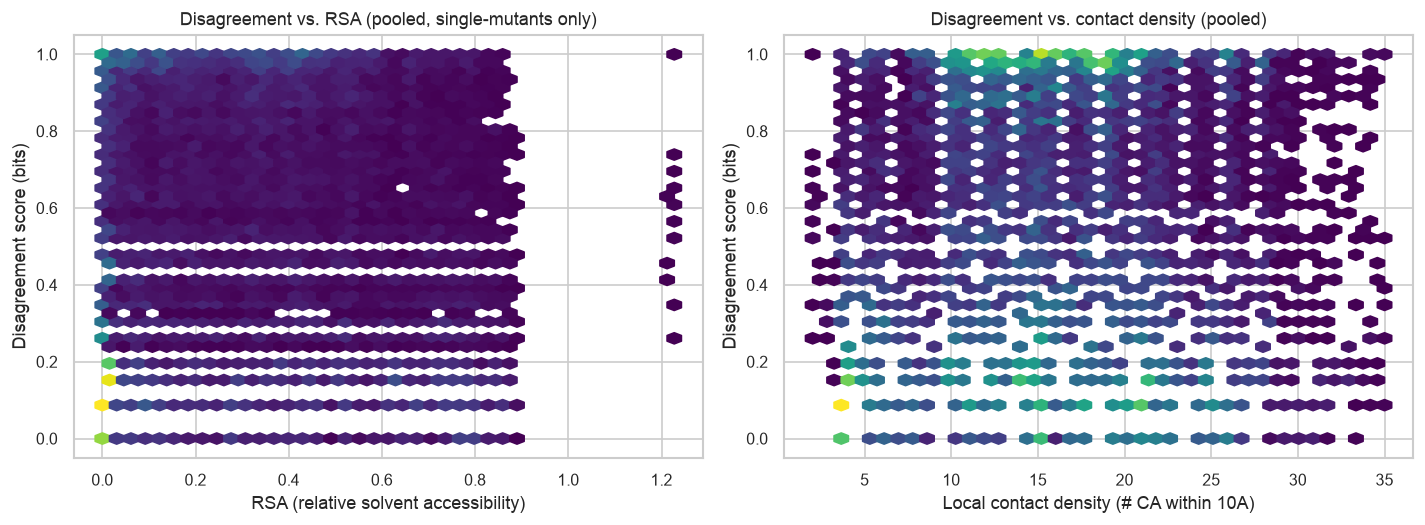

In [7]:
plot_df = df.dropna(subset=["disagreement_score", "rsa"])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hexbin(plot_df["rsa"], plot_df["disagreement_score"], gridsize=40, cmap="viridis", mincnt=1)
axes[0].set_xlabel("RSA (relative solvent accessibility)")
axes[0].set_ylabel("Disagreement score (bits)")
axes[0].set_title("Disagreement vs. RSA (pooled, single-mutants only)")

axes[1].hexbin(plot_df["contact_density"], plot_df["disagreement_score"], gridsize=40, cmap="viridis", mincnt=1)
axes[1].set_xlabel("Local contact density (# CA within 10A)")
axes[1].set_ylabel("Disagreement score (bits)")
axes[1].set_title("Disagreement vs. contact density (pooled)")

plt.tight_layout()
save_figure(
    fig, "disagreement_vs_structure_hexbin", notebook=NB,
    description="Disagreement score vs. RSA and local contact density, pooled across the 4 structurally-resolved pilots",
)
plt.show()


  [saved table]  results/tables/disagreement_by_secondary_structure.csv


  [saved figure] results/figures/disagreement_by_secondary_structure_bar.png


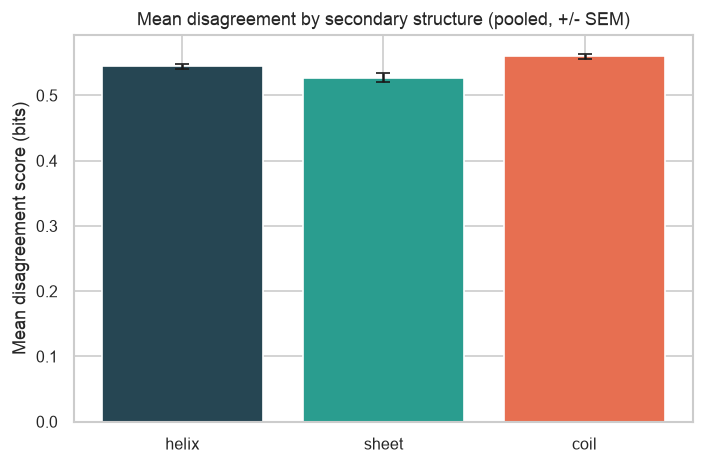

In [8]:
ss_stats = disagreement_by_secondary_structure(df)
save_table(
    ss_stats, "disagreement_by_secondary_structure", notebook=NB,
    description="Mean/median/std disagreement_score by secondary structure category (helix/sheet/coil), pooled and per assay",
)

pooled_ss = ss_stats[ss_stats["dms_id"] == "ALL"].set_index("secondary_structure")
fig, ax = plt.subplots(figsize=(6, 4))
order = ["helix", "sheet", "coil"]
ax.bar(order, pooled_ss.loc[order, "mean"], yerr=pooled_ss.loc[order, "std"] / np.sqrt(pooled_ss.loc[order, "count"]), capsize=4, color=["#264653", "#2a9d8f", "#e76f51"])
ax.set_ylabel("Mean disagreement score (bits)")
ax.set_title("Mean disagreement by secondary structure (pooled, +/- SEM)")
plt.tight_layout()

save_figure(
    fig, "disagreement_by_secondary_structure_bar", notebook=NB,
    description="Mean disagreement score by secondary structure category, pooled across the 4 structurally-resolved pilots",
)
plt.show()


## 4  Cluster accuracy re-stratified by structural context

Does the Week 2 cluster ranking hold uniformly across structural contexts, or
does a given cluster's edge concentrate in specific regions (e.g. does
`newer_plm` win everywhere, or specifically at buried/exposed positions)?


In [9]:
acc_by_ss = cluster_accuracy_by_structural_bin(df, cluster_votes, "secondary_structure")
save_table(
    acc_by_ss, "cluster_accuracy_by_secondary_structure", notebook=NB,
    description="Per-cluster majority-vote MCC/accuracy, grouped by secondary structure category (helix/sheet/coil)",
)

df["rsa_bin"] = pd.cut(df["rsa"], bins=[-np.inf, 0.25, np.inf], labels=["buried", "exposed"])
acc_by_rsa = cluster_accuracy_by_structural_bin(df, cluster_votes, "rsa_bin")
save_table(
    acc_by_rsa, "cluster_accuracy_by_rsa_bin", notebook=NB,
    description="Per-cluster majority-vote MCC/accuracy, grouped by RSA bin (buried: RSA<0.25, exposed: RSA>=0.25)",
)

print(acc_by_ss.pivot(index="cluster", columns="secondary_structure", values="mcc").round(3))
print()
print(acc_by_rsa.pivot(index="cluster", columns="rsa_bin", values="mcc").round(3))


  [saved table]  results/tables/cluster_accuracy_by_secondary_structure.csv
  [saved table]  results/tables/cluster_accuracy_by_rsa_bin.csv
secondary_structure     coil  helix  sheet
cluster                                   
autoregressive_plm     0.479  0.384  0.645
inverse_folding_mixed  0.391  0.374  0.467
msa_based              0.417  0.366  0.570
newer_plm              0.476  0.403  0.572
structure_aware        0.392  0.379  0.538

rsa_bin                buried  exposed
cluster                               
autoregressive_plm      0.360    0.356
inverse_folding_mixed   0.333    0.301
msa_based               0.319    0.304
newer_plm               0.378    0.354
structure_aware         0.332    0.306


  [saved figure] results/figures/cluster_accuracy_by_structure_heatmap.png


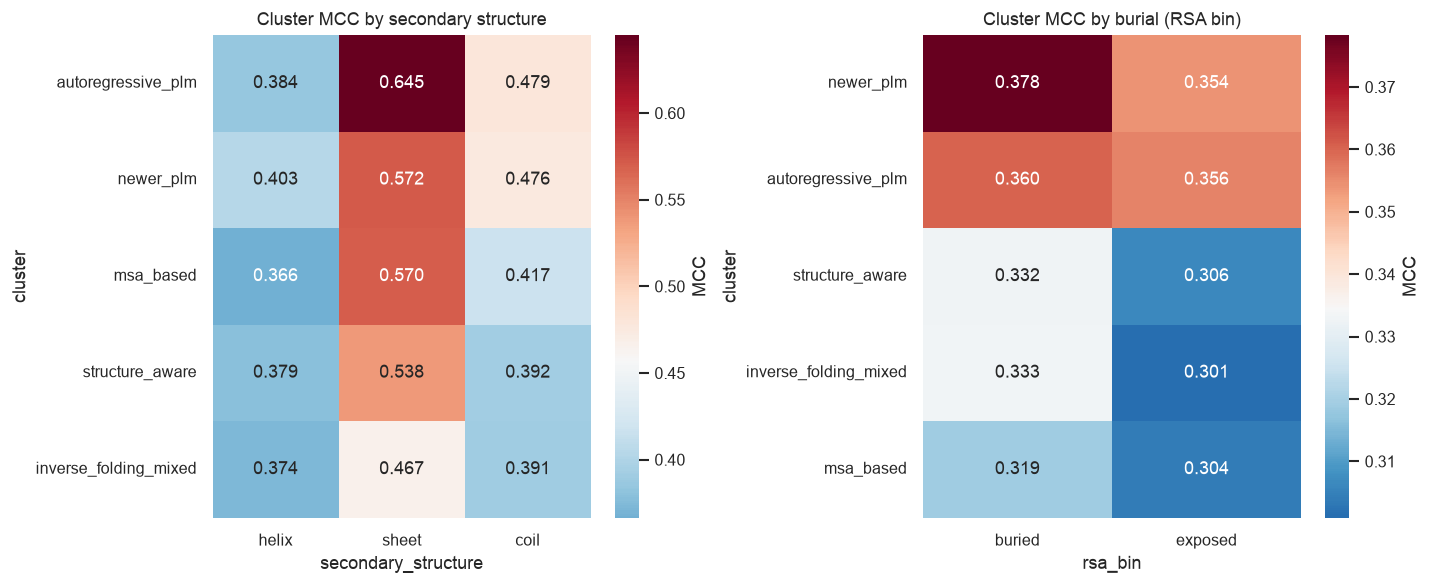

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ss_pivot = acc_by_ss.pivot(index="cluster", columns="secondary_structure", values="mcc")[["helix", "sheet", "coil"]]
ss_pivot = ss_pivot.loc[ss_pivot.mean(axis=1).sort_values(ascending=False).index]
sns.heatmap(ss_pivot, annot=True, fmt=".3f", cmap="RdBu_r", center=ss_pivot.values.mean(), ax=axes[0], cbar_kws={"label": "MCC"})
axes[0].set_title("Cluster MCC by secondary structure")

rsa_pivot = acc_by_rsa.pivot(index="cluster", columns="rsa_bin", values="mcc")[["buried", "exposed"]]
rsa_pivot = rsa_pivot.loc[rsa_pivot.mean(axis=1).sort_values(ascending=False).index]
sns.heatmap(rsa_pivot, annot=True, fmt=".3f", cmap="RdBu_r", center=rsa_pivot.values.mean(), ax=axes[1], cbar_kws={"label": "MCC"})
axes[1].set_title("Cluster MCC by burial (RSA bin)")

plt.tight_layout()
save_figure(
    fig, "cluster_accuracy_by_structure_heatmap", notebook=NB,
    description="Per-cluster majority-vote MCC broken out by secondary structure and by RSA bin (buried vs. exposed)",
)
plt.show()


## 5  Trust map: when is the consensus reliable?

Bin variants by disagreement level (tertiles) x burial (buried/exposed), and
check the all-model ensemble's accuracy in each cell. This is the seed of a
meta-confidence signal: a cell where accuracy holds up despite high
disagreement means disagreement there is informative-but-not-disqualifying; a
cell where accuracy collapses at high disagreement marks where the consensus
actually becomes unreliable.


  [saved table]  results/tables/consensus_trust_map.csv
  [saved figure] results/figures/consensus_trust_map.png


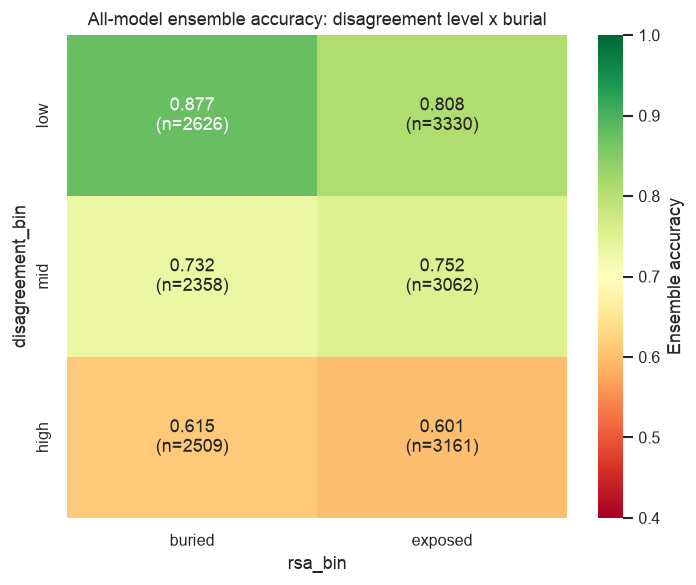

In [11]:
tmap = trust_map(df, ensemble_vote)
save_table(
    tmap, "consensus_trust_map", notebook=NB,
    description="All-model ensemble accuracy/MCC binned by disagreement tertile x RSA bin (buried/exposed) -- seed of a meta-confidence signal",
)

pivot_acc = tmap.pivot(index="disagreement_bin", columns="rsa_bin", values="accuracy").loc[["low", "mid", "high"], ["buried", "exposed"]]
pivot_n = tmap.pivot(index="disagreement_bin", columns="rsa_bin", values="n").loc[["low", "mid", "high"], ["buried", "exposed"]]
annot = pivot_acc.round(3).astype(str) + "\n(n=" + pivot_n.astype(int).astype(str) + ")"

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(pivot_acc, annot=annot, fmt="", cmap="RdYlGn", vmin=0.4, vmax=1.0, ax=ax, cbar_kws={"label": "Ensemble accuracy"})
ax.set_title("All-model ensemble accuracy: disagreement level x burial")
plt.tight_layout()

save_figure(
    fig, "consensus_trust_map", notebook=NB,
    description="Heatmap of all-model ensemble accuracy binned by disagreement tertile and RSA bin (buried/exposed), with cell sample sizes",
)
plt.show()


## Week 3 findings

Anchor question: does structural context explain where models disagree and why the Week 2 cluster ranking holds or breaks down?

**Structural coverage.** AlphaFold DB has reference structures for 4/5 pilots (A4_HUMAN, ADRB2_HUMAN, ACE2_HUMAN, AMIE_PSEAE). `A0A192B1T2_9HIV1` (HIV Env) has no model -- unreviewed, hypervariable TrEMBL entry -- and is excluded from every structural table. Structural features also only apply to single-mutant variants (position parses to a single residue): 17,046 / 43,638 total variants (39%) carry structural features. Three of the four resolved proteins (ADRB2, ACE2, AMIE) are 100% single-mutant; **A4_HUMAN is 95% multi-mutant, so its structural sample is small (796 variants, 5.4%)** -- treat A4_HUMAN's structural numbers as lower-confidence than the other three.

**Disagreement vs. RSA/contact density: weak and protein-dependent, not universal.** Pooled Spearman r(disagreement, RSA) = -0.035 (barely significant despite n=17,046) -- essentially no consistent pooled relationship. Per-protein signs disagree: A4_HUMAN shows a real effect (r=-0.39, models disagree *more* when buried; contact density r=+0.44 corroborates), but ACE2 is near zero (r=-0.10) and ADRB2/AMIE are *positive* (r=+0.05, +0.09 -- models disagree slightly *more* when exposed). **There is no single "buried positions are harder" rule across these 4 proteins** -- if one exists, it's protein-specific and this sample can't resolve a universal version of it.

**Disagreement by secondary structure: small effect.** Pooled mean disagreement is coil 0.560 > helix 0.545 > sheet 0.527 bits -- beta sheets show the least disagreement, consistent with sheets being the most structurally constrained/evolutionarily conserved context, but the spread across categories (~0.03 bits) is small relative to the overall distribution.

**Cluster ranking under structural stratification is confounded by which variants got included, not a clean structural effect.** Restricting to the single-mutant/4-protein subset *without any structural stratification at all* already reshuffles the Week 2 ranking: `autoregressive_plm` MCC jumps to 0.452, essentially tying `newer_plm` (0.453), because AMIE (which strongly favors `autoregressive_plm`, MCC 0.559 in Week 2) now has more relative weight in the pool once HIV Env and A4_HUMAN's multi-mutants drop out. Pooled RSA/secondary-structure stratification on top of this subset shows `newer_plm` leading in buried/helix contexts and `autoregressive_plm` leading in exposed/sheet/coil contexts -- but checking **within each individual protein**, the "winning cluster" per RSA bin is inconsistent and doesn't match this pooled pattern (ADRB2: `inverse_folding_mixed` wins buried, `newer_plm` wins exposed; ACE2: `structure_aware` wins buried, `inverse_folding_mixed` wins exposed; AMIE: `newer_plm` wins buried, `autoregressive_plm` wins exposed). **Protein identity, not structural bin, remains the dominant driver of which cluster wins** -- consistent with Week 2's finding that per-assay winners vary by protein. Structural bins are too small per protein (700-4,800 variants) and too few proteins (4) to separate a real structural effect from protein-identity noise here.

**Trust map: the one clean, robust finding.** All-model ensemble accuracy drops monotonically as disagreement increases, in both RSA bins: buried 0.877 (low disagreement) -> 0.732 (mid) -> 0.615 (high); exposed 0.808 -> 0.752 -> 0.601. This holds regardless of burial state, confirming Week 1's premise that `disagreement_score` is a real signal of prediction unreliability, not noise. The one structural nuance: **at high disagreement, buried-position consensus retains more signal than exposed-position consensus** (MCC 0.216 buried vs. 0.153 exposed) -- when models disagree at a buried/packed position, the ensemble is still more likely to be right than when they disagree at an exposed one, plausibly because buried positions are more evolutionarily constrained and even discordant models retain some real structural signal, while exposed-position disagreement is closer to a coin flip.

**Implication for write-up / Week 4:** structural context (RSA, secondary structure) does not cleanly explain the Week 2 cluster ranking or resolve disagreement at the single-protein level with only 4 structurally-resolved pilots -- the dominant driver is still which protein you're looking at. The trust-map result (disagreement predicts ensemble unreliability, more so at exposed positions) is solid and worth carrying forward. Before drawing stronger structural conclusions, Week 4 should either (a) scale to more ProteinGym assays with AlphaFold coverage to get enough per-(protein x structural-bin) sample size to separate structure from protein identity, or (b) run the structural stratification within-protein only (never pooling across proteins) to avoid the confound documented above.
